# 65 — Where does `log` belong in the signal pipeline?

We want to take the log of the FFT magnitude. The question is **where**: before or after
`extract_signal`, `subtract_speaker_mean`, `normalize_fft`, `tokenize`, `normalize_token`.

The current pipeline (`process_vibration`, `src/model/dataset.py`) is:

```
augment (complex)  ->  extract_signal (abs)  ->  subtract_speaker_mean
                   ->  normalize_fft (/std)  ->  tokenize  ->  normalize_token (/patch mean)
```

Every step after `extract_signal` is a **subtraction** or a **division**, and log converts one
into the other. So the ordering is not cosmetic — it changes what the operation *means*:

| step | linear space | log space |
|---|---|---|
| `subtract_speaker_mean` | removes an *additive* offset | divides out a *multiplicative* gain |
| `normalize_fft(std)` | rescales | rescales the *log*, i.e. a power law on the raw signal |
| `normalize_fft(z)` | centers + rescales | centers + rescales |
| `normalize_token(/mean)` | divides by patch mean | **ill-defined** — log means cross zero |

This notebook plots 10 real `experiment-25` samples under every combination so we can *see*
which orderings are sane instead of arguing from theory.

**The three things to look for**

1. **Dynamic range** — raw magnitudes span ~237 dB across samples. Does log tame it?
2. **The epsilon** — `log(x + eps)`. Bins near the numerical floor (min seen: `1.2e-8`) blow up
   to large negative values and can dominate the variance. §4 sweeps eps to pick one.
3. **Does normalization still do anything?** — if you log *after* dividing by std, you have only
   added the constant `-log(std)`, which the first `nn.Linear` absorbs. The normalization becomes
   a no-op. §5 tests this numerically.

In [1]:
import json
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch
from tqdm.auto import tqdm

sys.path.insert(0, str(Path.cwd().parent / "src"))
from model.dataset import extract_signal, normalize_fft, tokenize, normalize_token

EXP = Path.cwd().parent / "experiments" / "experiment-25"
FFT = "vibration/04_fft.npz"
PATCH_SIZE = 64
N_SAMPLES = 10
SEED = 42

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
                     "axes.spines.top": False, "axes.spines.right": False})

/home/ethantu/workspace/good-vibrations/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


## 0. Load 10 samples

We spread the picks across the sample directory rather than taking the first 10, so we get a mix
of speakers / positions / layouts instead of 10 near-duplicates from one capture.

`fft` is `(1, L, F, C)` complex64 — L=100 lasers, F=2946 freq bins (50–1000 Hz), C=2 channels
(x/y). We keep the **raw complex** array so every transform below starts from the same place.

In [2]:
def meta_of(d: Path) -> dict:
    return {k: v for line in open(d / "metadata.jsonl") if line.strip()
            for k, v in json.loads(line).items()}

all_dirs = [d for d in sorted((EXP / "samples").glob("*")) if (d / FFT).exists()]
rng = np.random.default_rng(SEED)
dirs = [all_dirs[i] for i in sorted(rng.choice(len(all_dirs), N_SAMPLES, replace=False))]

samples = []
for d in tqdm(dirs, desc="loading"):
    z = np.load(d / FFT)
    fft = z["fft"]
    if fft.ndim == 4 and fft.shape[0] == 1: fft = fft[0]          # (L,F,C)
    m = meta_of(d)
    samples.append(dict(name=d.name, fft=torch.from_numpy(fft).unsqueeze(0),  # (1,L,F,C)
                        speaker=int(m.get("speaker", -1)),
                        position=int(m.get("position_id", m.get("output_id", -1))),
                        layout=m.get("layout", "?")))

FREQS = torch.from_numpy(np.load(dirs[0] / FFT)["freqs"])
L, F_, C = samples[0]["fft"].shape[1:]
print(f"{len(samples)} samples | L={L} lasers, F={F_} bins ({FREQS.min():.0f}-{FREQS.max():.0f} Hz), C={C}")
for s in samples:
    print(f"  {s['name']}  speaker={s['speaker']:>2}  position={s['position']:>3}  {s['layout']}")

loading:   0%|          | 0/10 [00:00<?, ?it/s]

10 samples | L=100 lasers, F=2946 bins (50-1000 Hz), C=2
  000088  speaker= 8  position= 10  purple-cube
  000091  speaker= 3  position= 11  purple-cube
  000097  speaker= 1  position= 12  purple-cube
  000207  speaker= 7  position= 25  purple-cube
  000442  speaker= 2  position= 55  purple-cube
  000447  speaker= 7  position= 55  purple-cube
  000666  speaker= 2  position= 83  purple-cube-green-cube
  000713  speaker= 1  position= 89  purple-cube-green-cube
  000787  speaker= 3  position= 98  purple-cube-green-cube
  000876  speaker= 4  position=109  purple-cube-green-cube


## 1. The raw magnitude problem

Before any transform: what does `|fft|` actually look like? This is the motivation for logging at
all. We plot the per-frequency spectrum (mean over lasers and channels) for all 10 samples, on
linear and log y-axes.

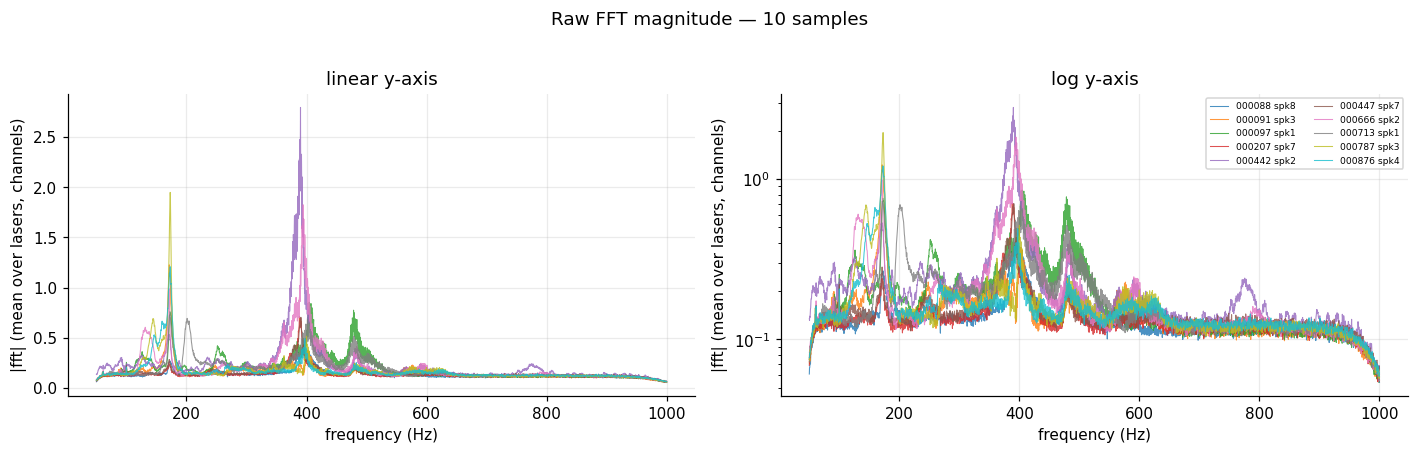

pooled |fft| percentiles [0, .01, .1, 1, 50, 99, 99.9, 100]:
       0% : 1.73132e-09
    0.01% : 4.5497e-08
     0.1% : 3.29787e-06
       1% : 0.00916892
      50% : 0.12387
      99% : 0.969145
    99.9% : 2.55297
     100% : 12.629

exact zeros: 0
dynamic range: 197 dB


In [3]:
def spectrum(x: torch.Tensor) -> np.ndarray:
    """(1,L,F,C) -> (F,) mean over lasers+channels."""
    return x.squeeze(0).mean(dim=(0, 2)).numpy()

mags = [s["fft"].abs() for s in samples]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, logy in zip(axes, [False, True]):
    for s, m in zip(samples, mags):
        ax.plot(FREQS, spectrum(m), lw=0.7, alpha=0.8, label=f"{s['name']} spk{s['speaker']}")
    if logy: ax.set_yscale("log")
    ax.set(xlabel="frequency (Hz)", ylabel="|fft| (mean over lasers, channels)",
           title=("log y-axis" if logy else "linear y-axis"))
axes[1].legend(fontsize=6, ncol=2)
fig.suptitle("Raw FFT magnitude — 10 samples", y=1.02)
plt.tight_layout(); plt.show()

allmag = torch.cat([m.flatten() for m in mags])
qs = np.percentile(allmag.numpy(), [0, 0.01, 0.1, 1, 50, 99, 99.9, 100])
print("pooled |fft| percentiles [0, .01, .1, 1, 50, 99, 99.9, 100]:")
for q, v in zip([0, .01, .1, 1, 50, 99, 99.9, 100], qs): print(f"  {q:>6}% : {v:.6g}")
print(f"\nexact zeros: {(allmag == 0).sum().item()}")
print(f"dynamic range: {20*np.log10(qs[-1]/max(qs[0], 1e-30)):.0f} dB")

**Read this before moving on.** On the linear axis a handful of tall peaks (the speaker excitation
band) hide everything else; the log axis reveals structure across the whole band. That is the case
*for* logging.

The catch is the bottom end. There are no exact zeros, but the minimum runs to ~`1e-8` while the
median sits near `0.1` — those near-dead bins are what makes the eps choice in §4 matter.

## 2. The transform zoo

We define each pipeline step as a small named function so orderings can be composed as a list.
These mirror `src/model/dataset.py` exactly, except `log` which is what we are designing.

`normalize_token` is applied on the tokenized `(B,L,P,PS,C)` shape, so pipelines that use it run
`tokenize` first; we flatten back to `(F,)` for plotting afterwards.

In [4]:
LOG_EPS = 1e-3   # default; swept in section 4

def op_abs(x, **kw):      return extract_signal(x, "magnitude").float()
def op_log(x, eps=None, **kw): return torch.log(x + (LOG_EPS if eps is None else eps))
def op_std(x, **kw):      return normalize_fft(x, "std")
def op_z(x, **kw):        return normalize_fft(x, "z")

def op_tok_mean(x, **kw):
    """tokenize -> divide by per-patch mean -> flatten back to (B,L,F,C)."""
    t = normalize_token(tokenize(x, PATCH_SIZE), "std+token-mean")
    B, Lc, P, PS, Cc = t.shape
    return t.reshape(B, Lc, P * PS, Cc)[:, :, :x.shape[2]]

def op_tok_sub(x, **kw):
    """log-space analogue of token-mean: SUBTRACT the per-patch mean instead of dividing."""
    t = tokenize(x, PATCH_SIZE)
    mean = t.double().mean(dim=(1, 3, 4), keepdim=True).float()
    t = t - mean
    B, Lc, P, PS, Cc = t.shape
    return t.reshape(B, Lc, P * PS, Cc)[:, :, :x.shape[2]]

def run(fft, ops, **kw):
    x = fft
    for f in ops: x = f(x, **kw)
    return x

OPNAME = {op_abs: "abs", op_log: "log", op_std: "std", op_z: "z",
          op_tok_mean: "tok/mean", op_tok_sub: "tok-mean"}
def label(ops): return " -> ".join(OPNAME[f] for f in ops)

## 3. Ordering comparison

Each panel is one pipeline, all 10 samples overplotted. What we want to see in a good panel:

- the 10 curves **land on a common scale** (so the model sees consistent input across samples),
- **structure is still visible** (curves are not flattened into noise),
- no sample is a wild outlier.

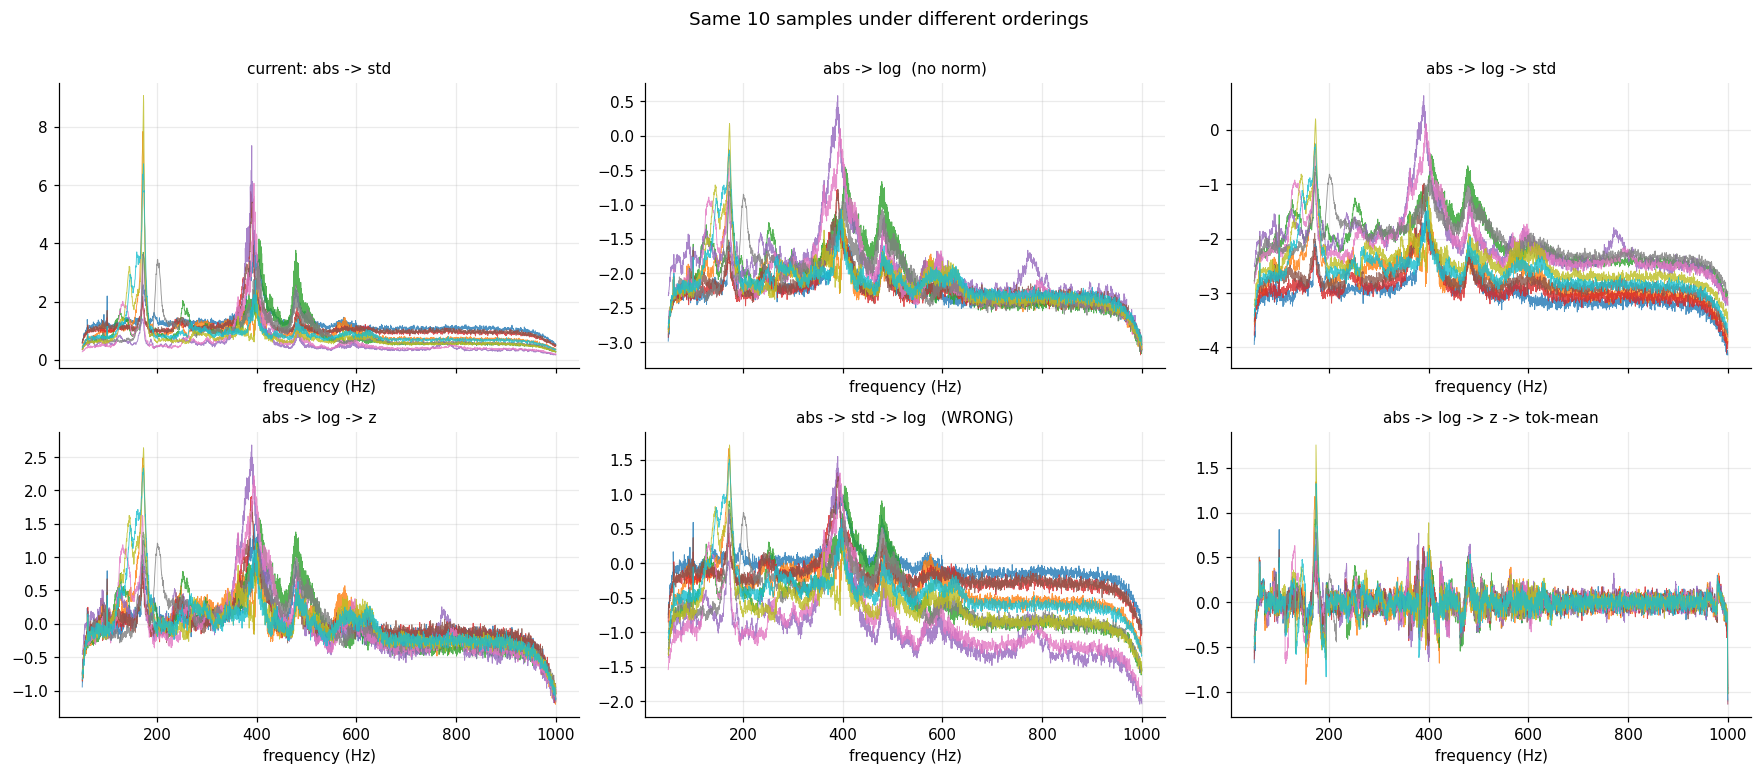

In [5]:
PIPELINES = [
    ("current: abs -> std",            [op_abs, op_std]),
    ("abs -> log  (no norm)",          [op_abs, op_log]),
    ("abs -> log -> std",              [op_abs, op_log, op_std]),
    ("abs -> log -> z",                [op_abs, op_log, op_z]),
    ("abs -> std -> log   (WRONG)",    [op_abs, op_std, op_log]),
    ("abs -> log -> z -> tok-mean",    [op_abs, op_log, op_z, op_tok_sub]),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 7), sharex=True)
for ax, (title, ops) in zip(axes.flat, PIPELINES):
    for s in samples:
        ax.plot(FREQS, spectrum(run(s["fft"], ops)), lw=0.6, alpha=0.8)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("frequency (Hz)")
fig.suptitle("Same 10 samples under different orderings", y=1.00)
plt.tight_layout(); plt.show()

In [6]:
# Numeric summary: per-sample mean/std of the FINAL tensor, and how much they vary ACROSS samples.
# A good pipeline has low across-sample spread in mean/std (consistent scale) while keeping
# non-trivial within-sample std (structure preserved).
rows = []
for title, ops in PIPELINES:
    outs = [run(s["fft"], ops) for s in samples]
    mu = np.array([o.mean().item() for o in outs])
    sd = np.array([o.std().item() for o in outs])
    lo = np.array([o.min().item() for o in outs])
    hi = np.array([o.max().item() for o in outs])
    rows.append(dict(pipeline=title, mean=mu.mean(), std=sd.mean(),
                     mean_spread=mu.std(), std_spread=sd.std(),
                     min=lo.min(), max=hi.max()))

import pandas as pd
df = pd.DataFrame(rows).set_index("pipeline")
pd.set_option("display.width", 200, "display.float_format", lambda v: f"{v:9.4f}")
print(df)
print("\nmean_spread / std_spread = variation ACROSS the 10 samples (lower = more consistent scale)")

                                 mean       std  mean_spread  std_spread       min       max
pipeline                                                                                    
current: abs -> std            0.9422    1.0000       0.1926      0.0000    0.0000   35.3210
abs -> log  (no norm)         -2.1263    0.8761       0.1055      0.0982   -6.9078    2.5361
abs -> log -> std             -2.4663    1.0000       0.3654      0.0000   -8.9504    2.7408
abs -> log -> z               -0.0000    1.0000       0.0000      0.0000   -5.9534    4.7940
abs -> std -> log   (WRONG)   -0.4523    0.8998       0.2809      0.1184   -6.9077    3.5645
abs -> log -> z -> tok-mean   -0.0007    0.9161       0.0000      0.0322   -6.6067    3.8699

mean_spread / std_spread = variation ACROSS the 10 samples (lower = more consistent scale)


## 4. Choosing the epsilon

`log(x + eps)` needs an eps. Too large and it crushes the low end back into a constant (undoing
the log); too small and near-dead bins (min `~1e-8`) explode to huge negative values and dominate
the variance — which then poisons the `std` divisor downstream.

We sweep eps and track two things:

- **`min`** of the output — how far the dead bins fall,
- **`std`** — inflated std means the dead bins are running the show,
- **`corr vs eps=median`** — how much the *shape* of the spectrum changes relative to a sane
  reference. Once this saturates, larger eps is only flattening the signal.

median |fft| = 0.1239   (used as the reference eps)
              min      mean       std      corr
eps                                            
 0.0000  -20.1738   -2.1496    0.9962    0.8668
 0.0000  -18.2610   -2.1495    0.9949    0.8679
 0.0000  -13.8138   -2.1475    0.9694    0.8871
 0.0001   -9.2103   -2.1414    0.9220    0.9224
 0.0010   -6.9078   -2.1263    0.8878    0.9408
 0.0100   -4.6052   -2.0213    0.7821    0.9689
 0.1000   -2.3026   -1.4344    0.4697    0.9996
 0.1239   -2.0885   -1.3307    0.4323    1.0000
 1.0000    0.0000    0.1492    0.1331    0.9588
10.0000    2.3026    2.3196    0.0198    0.8786


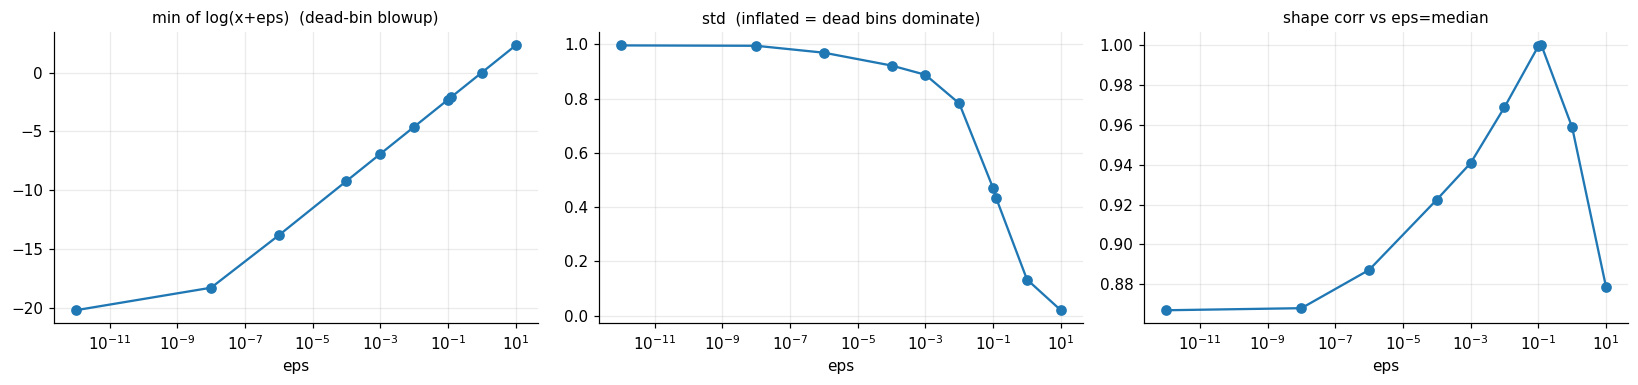

In [7]:
med = float(torch.median(torch.cat([m.flatten() for m in mags])))
EPS_GRID = [1e-12, 1e-8, 1e-6, 1e-4, 1e-3, 1e-2, 1e-1, med, 1.0, 10.0]

ref = torch.cat([torch.log(m + med).flatten() for m in mags])
rows = []
for eps in EPS_GRID:
    vals = torch.cat([torch.log(m + eps).flatten() for m in mags])
    rows.append(dict(eps=eps, min=vals.min().item(), mean=vals.mean().item(),
                     std=vals.std().item(),
                     corr=float(np.corrcoef(vals.numpy(), ref.numpy())[0, 1])))
df_eps = pd.DataFrame(rows).set_index("eps")
print(f"median |fft| = {med:.4g}   (used as the reference eps)")
print(df_eps)

fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
for ax, col, t in zip(axes, ["min", "std", "corr"],
                      ["min of log(x+eps)  (dead-bin blowup)",
                       "std  (inflated = dead bins dominate)",
                       "shape corr vs eps=median"]):
    ax.plot(df_eps.index, df_eps[col], "o-")
    ax.set_xscale("log"); ax.set_xlabel("eps"); ax.set_title(t, fontsize=10)
plt.tight_layout(); plt.show()

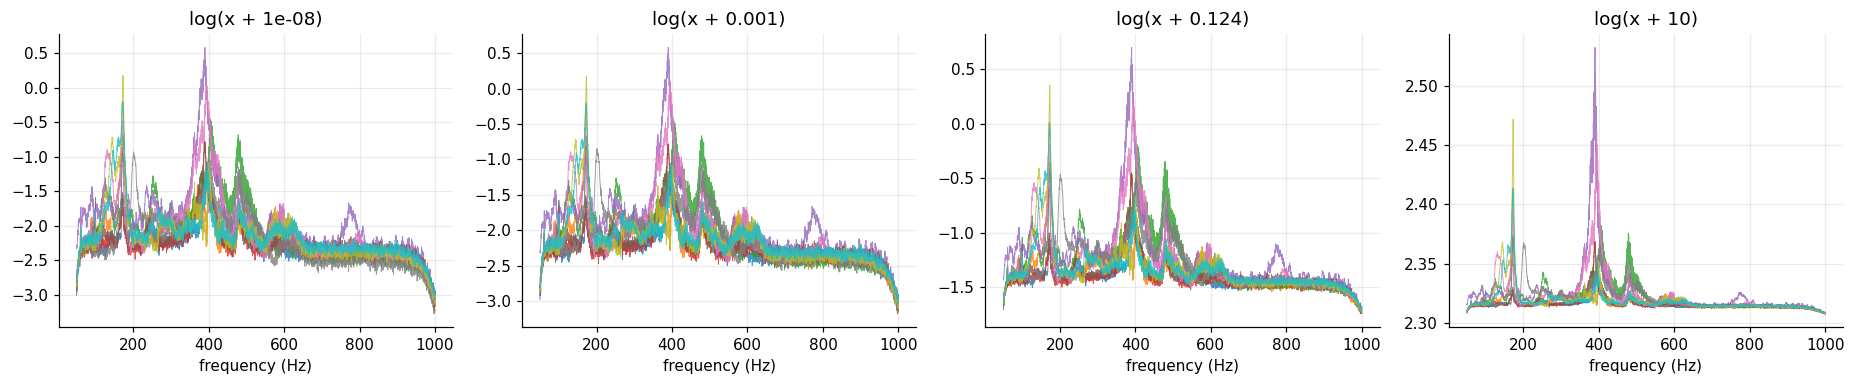

In [8]:
# Visual: the spectrum itself under a few epsilons.
fig, axes = plt.subplots(1, 4, figsize=(17, 3.6), sharex=True)
for ax, eps in zip(axes, [1e-8, 1e-3, med, 10.0]):
    for m in mags:
        ax.plot(FREQS, spectrum(torch.log(m + eps)), lw=0.6, alpha=0.8)
    ax.set(title=f"log(x + {eps:.3g})", xlabel="frequency (Hz)")
plt.tight_layout(); plt.show()

## 5. Does normalizing *after* the log still do anything?

The intuition is that `abs -> std -> log` is broken because

```
log(x / std) = log(x) - log(std)
```

looks like `log(x)` shifted by a per-sample constant — and a `nn.Linear` bias absorbs any constant,
so the normalization would have contributed nothing.

**The measurement below only partly supports that.** The residual spread is not zero (~1e-2 to
1e-1), because `normalize_fft("std")` divides by a std taken over dims (1,2,3) *without centering*
and computed in float64 before a float32 divide — so it is not exactly one scalar per sample.

The decisive evidence is the **second block**: after `abs->std->log` the per-sample stds still
vary (0.77 to 1.14), i.e. the tensors reaching the model are on *different scales per sample* —
the normalization did not survive the log. After `abs->log->std` or `abs->log->z` every per-sample
std is exactly 1.0. That is the real argument for logging first.

In [9]:
a = [run(s["fft"], [op_abs, op_std, op_log]) for s in samples]   # normalize then log
b = [run(s["fft"], [op_abs, op_log]) for s in samples]           # just log

print("How close is (abs->std->log) to (abs->log) plus a per-sample constant?\n")
for s, x, y in zip(samples, a, b):
    d = (x - y).flatten()
    print(f"  {s['name']}: offset={d.mean():+8.4f}  residual spread={d.std():.2e}  "
          f"{'~constant offset' if d.std() < 1e-4 else 'not a pure constant'}")

print("\nPer-sample std AFTER each pipeline (this is what reaches the model):")
for name, ops in [("abs->std->log", [op_abs, op_std, op_log]),
                  ("abs->log->std", [op_abs, op_log, op_std]),
                  ("abs->log->z",   [op_abs, op_log, op_z])]:
    sds = [run(s["fft"], ops).std().item() for s in samples]
    print(f"  {name:>14}: std per sample = [{', '.join(f'{v:.3f}' for v in sds)}]")
print("\n-> a pipeline whose per-sample stds are all 1.0 has genuinely normalized scale;")
print("   one with varying stds has not (the log only shifted them).")

How close is (abs->std->log) to (abs->log) plus a per-sample constant?

  000088: offset= +2.2511  residual spread=1.83e-02  not a pure constant
  000091: offset= +1.8443  residual spread=1.64e-02  not a pure constant
  000097: offset= +1.5634  residual spread=9.24e-02  not a pure constant
  000207: offset= +2.0865  residual spread=1.83e-02  not a pure constant
  000442: offset= +0.9604  residual spread=1.19e-02  not a pure constant
  000447: offset= +2.0286  residual spread=1.87e-02  not a pure constant
  000666: offset= +1.1913  residual spread=2.45e-02  not a pure constant
  000713: offset= +1.5788  residual spread=1.60e-01  not a pure constant
  000787: offset= +1.5273  residual spread=1.84e-02  not a pure constant
  000876: offset= +1.7080  residual spread=1.50e-02  not a pure constant

Per-sample std AFTER each pipeline (this is what reaches the model):
   abs->std->log: std per sample = [0.769, 0.808, 1.057, 0.789, 0.933, 0.810, 0.980, 1.137, 0.892, 0.825]
   abs->log->std: std 

## 6. Why `normalize_token`'s divide breaks in log space

`normalize_token` divides each patch by its own mean, with `clamp_min(1e-8)`. In linear space the
patch mean is a positive magnitude, so this is a sane per-band gain normalization.

In log space the values are **signed** and the patch mean passes through zero. `clamp_min(1e-8)`
then turns a near-zero mean into a division by `1e-8` — a ~1e8x amplification. We count how often
the mean lands near zero or negative.

In [10]:
logged = [run(s["fft"], [op_abs, op_log, op_z]) for s in samples]
t = torch.cat([tokenize(x, PATCH_SIZE) for x in logged], dim=0)   # (N,L,P,PS,C)
pm = t.double().mean(dim=(1, 3, 4))                                # (N,P) per-patch means

print(f"per-patch means over {pm.shape[0]} samples x {pm.shape[1]} patches:")
print(f"  min={pm.min():.4f}  max={pm.max():.4f}")
print(f"  negative      : {(pm < 0).sum().item():>5} / {pm.numel()}")
print(f"  |mean| < 0.01 : {(pm.abs() < 0.01).sum().item():>5} / {pm.numel()}   <- these explode when divided by")
print(f"\nafter clamp_min(1e-8) the largest amplification is x{(1/pm.clamp_min(1e-8)).max():.3g}")

blown = op_tok_mean(logged[0])
print(f"\nop_tok_mean on logged data -> min={blown.min():.4g}  max={blown.max():.4g}  "
      f"finite={torch.isfinite(blown).all().item()}")
sub = op_tok_sub(logged[0])
print(f"op_tok_sub  (subtract instead) -> min={sub.min():.4g}  max={sub.max():.4g}  "
      f"finite={torch.isfinite(sub).all().item()}")

per-patch means over 10 samples x 47 patches:
  min=-0.9498  max=2.0608
  negative      :   273 / 470
  |mean| < 0.01 :     9 / 470   <- these explode when divided by

after clamp_min(1e-8) the largest amplification is x1e+08

op_tok_mean on logged data -> min=-5.953e+08  max=2.784e+08  finite=True
op_tok_sub  (subtract instead) -> min=-6.607  max=3.032  finite=True


## 7. Speaker-mean placement

`subtract_speaker_mean` removes a per-speaker `(L,F,C)` mean spectrum. Its placement interacts
with the log the same way:

- **linear space**: the speaker's effect is a multiplicative gain, so *subtracting* a mean only
  partly removes it (it is the wrong inverse operation).
- **log space**: subtracting the mean-of-logs is exactly dividing out the geometric-mean gain —
  the right inverse.

The catch: the mean must be computed **on the same quantity it is subtracted from**. Subtracting a
linear-space mean from logged data is meaningless. We build both and compare how much speaker
structure each removes, measured as between-speaker variance as a fraction of total.

In [11]:
by_speaker = {}
for s in samples: by_speaker.setdefault(s["speaker"], []).append(s)
print("speakers in this subset:", {k: len(v) for k, v in sorted(by_speaker.items())})

def speaker_var_fraction(feats, speakers):
    """fraction of total variance explained by speaker identity."""
    X = np.stack(feats); sp = np.array(speakers)
    total = X.var(axis=0).sum()
    if total == 0: return 0.0
    between = sum((X[sp == s].mean(axis=0) - X.mean(axis=0)) ** 2 * (sp == s).sum() for s in np.unique(sp)).sum() / len(X)
    return float(between / total)

speakers = [s["speaker"] for s in samples]
for name, ops in [("abs",            [op_abs]),
                  ("abs -> std",     [op_abs, op_std]),
                  ("abs -> log",     [op_abs, op_log]),
                  ("abs -> log -> z",[op_abs, op_log, op_z])]:
    feats = [spectrum(run(s["fft"], ops)) for s in samples]
    print(f"  {name:>18}: speaker explains {speaker_var_fraction(feats, speakers):6.1%} of variance")

print("\n(with only 10 samples this is indicative, not conclusive -- raise N_SAMPLES to firm it up)")

speakers in this subset: {1: 2, 2: 2, 3: 2, 4: 1, 7: 2, 8: 1}
                 abs: speaker explains  84.1% of variance
          abs -> std: speaker explains  87.3% of variance
          abs -> log: speaker explains  83.6% of variance
     abs -> log -> z: speaker explains  82.2% of variance

(with only 10 samples this is indicative, not conclusive -- raise N_SAMPLES to firm it up)


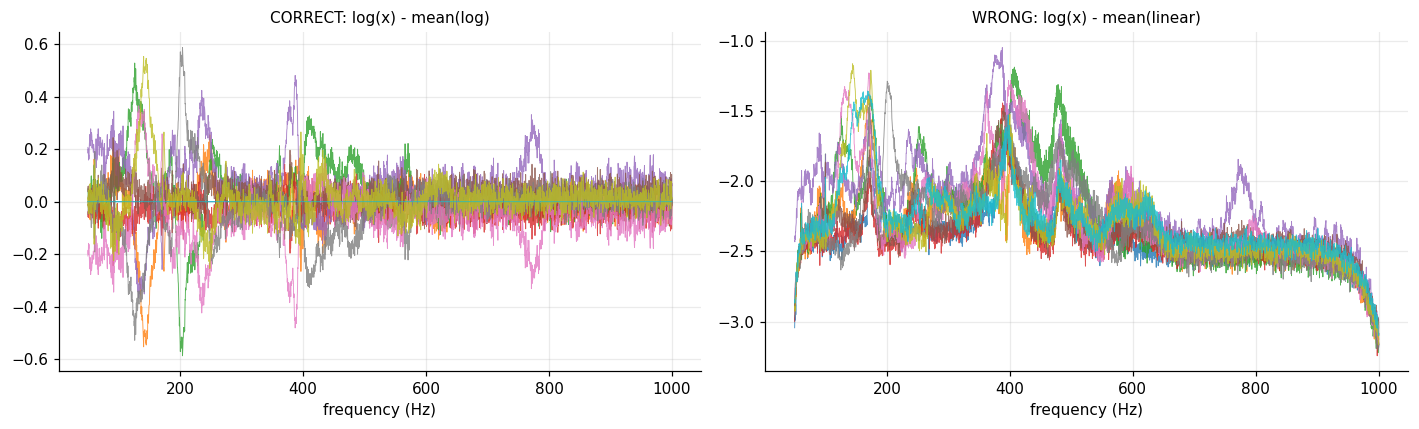

In [12]:
# Correct vs incorrect speaker-mean subtraction, on the LOG signal.
# correct  : mean of logs, subtracted from logs
# incorrect: mean of linear magnitudes, subtracted from logs
log_feats = {s["name"]: run(s["fft"], [op_abs, op_log]) for s in samples}
lin_feats = {s["name"]: run(s["fft"], [op_abs]) for s in samples}

log_mean = {sp: torch.stack([log_feats[s["name"]] for s in g]).mean(0) for sp, g in by_speaker.items()}
lin_mean = {sp: torch.stack([lin_feats[s["name"]] for s in g]).mean(0) for sp, g in by_speaker.items()}

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharex=True)
for s in samples:
    good = log_feats[s["name"]] - log_mean[s["speaker"]]
    bad  = log_feats[s["name"]] - lin_mean[s["speaker"]]
    axes[0].plot(FREQS, spectrum(good), lw=0.6, alpha=0.8)
    axes[1].plot(FREQS, spectrum(bad), lw=0.6, alpha=0.8)
axes[0].set_title("CORRECT: log(x) - mean(log)", fontsize=10)
axes[1].set_title("WRONG: log(x) - mean(linear)", fontsize=10)
for ax in axes: ax.set_xlabel("frequency (Hz)")
plt.tight_layout(); plt.show()

## 8. Verdict

Fill this in from the plots above — but the structural constraints that do **not** depend on the
data are:

1. **log goes immediately after `extract_signal`.** It needs a real, non-negative input, so it
   cannot precede `abs` (and is undefined for `signal_mode="complex"`).
2. **log before `normalize_fft`.** §5 shows that normalizing first does not survive the log:
   per-sample stds still range 0.77-1.14 afterwards, so samples reach the model on different
   scales. Logging first gives exactly 1.0 for every sample.
3. **Use `z`, not `std`, with log.** `std` divides without centering; logged data sits at a large
   negative offset, so `z` is the one that actually centers it.
4. **`normalize_token`'s divide must become a subtract** (`op_tok_sub`) or be dropped — §6 shows
   the divide is numerically unsound on signed log values.
5. **`subtract_speaker_mean` must switch to a mean-of-logs** if it is used with log (§7), which
   means `compute_speaker_means` has to log before averaging.

### The eps (the one genuinely empirical choice)

From the §4 sweep on these 10 samples (pooled `|fft|`: min `1.7e-9`, median `0.124`, max `12.6`):

| eps | min of log | std | shape corr |
|---|---|---|---|
| `1e-12` | -20.2 | 1.00 | 0.87 |
| `1e-4` | -9.2 | 0.92 | 0.92 |
| `1e-3` | -6.9 | 0.89 | 0.94 |
| `1e-2` | -4.6 | 0.78 | 0.97 |
| `median (0.124)` | -2.1 | 0.43 | 1.00 |
| `10` | +2.3 | 0.02 | 0.88 |

There is no sharp knee — it is a smooth trade. Small eps lets dead bins fall to -20 and stretches
the std; large eps crushes the low end (at `eps=median` the std has collapsed to 0.43, i.e. the log
is barely doing anything anymore).

**`1e-2` to `1e-3` is the sensible band**: the floor stays bounded (-4.6 / -6.9) while the std is
still healthy. `1e-3` is the notebook default. Note this is *far* above the `1e-8` you might reach
for by analogy with `clamp_min` — at `1e-8` the dead bins hit -18 and dominate the variance.

Since `normalize_fft("z")` recenters afterwards, the absolute offset does not matter; only the
*relative* stretch of the low end does.